Folders Ready
eyes/test/Close  -->  8867 images
eyes/test/Open  -->  9084 images
eyes/train/Close  -->  26597 images
eyes/train/Open  -->  27246 images
eyes/val/Close  -->  8866 images
eyes/val/Open  -->  9084 images
yawn/yawn  -->  2528 images
yawn/no_yawn  -->  2591 images
Corrupt Images Removed
Removed Small Image: 1000.jpg
Removed Small Image: 1002.jpg
Removed Small Image: 1008.jpg
Removed Small Image: 1009.jpg
Removed Small Image: 1010.jpg
Removed Small Image: 1014.jpg
Removed Small Image: 102.jpg
Removed Small Image: 1024.jpg
Removed Small Image: 1032.jpg
Removed Small Image: 1036.jpg
Removed Small Image: 1044.jpg
Removed Small Image: 105.jpg
Removed Small Image: 1058.jpg
Removed Small Image: 108.jpg
Removed Small Image: 111.jpg
Removed Small Image: 1140.jpg
Removed Small Image: 118.jpg
Removed Small Image: 120.jpg
Removed Small Image: 121.jpg
Removed Small Image: 122.jpg
Removed Small Image: 124.jpg
Removed Small Image: 127.jpg
Removed Small Image: 1292.jpg
Removed Small Image: 

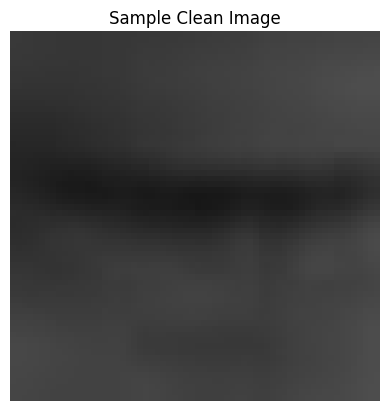

Preprocessing Completed
Edge Detection Applied


OSError: [WinError 112] There is not enough space on the disk: 'dim_light_dataset\\eyes/train/Open'

In [1]:
import os
import cv2
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ── OUTPUT FOLDERS ──
clean_path     = "clean_dataset"
processed_path = "processed_dataset"
edge_path      = "edge_dataset"
dim_path       = "dim_light_dataset"

for p in [clean_path, processed_path, edge_path, dim_path]:
    os.makedirs(p, exist_ok=True)

print("Folders Ready")


# ── STEP 3 : VIEW DATASET FOLDERS ──

source_folders = {
    "eyes/test/Close" : r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\test\Close",
    "eyes/test/Open"  : r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\test\Open",
    "eyes/train/Close": r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\train\Close",
    "eyes/train/Open" : r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\train\Open",
    "eyes/val/Close"  : r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\val\Close",
    "eyes/val/Open"   : r"C:\Users\semwa\Project_Bnat\archive (1)\data\eyes\val\Open",
    "yawn/yawn"       : r"C:\Users\semwa\Project_Bnat\archive (1)\data\yawn\yawn",
    "yawn/no_yawn"    : r"C:\Users\semwa\Project_Bnat\archive (1)\data\yawn\no yawn",
}

for key, path in source_folders.items():
    print(key, " --> ", len(os.listdir(path)), "images")


# ── STEP 4 : REMOVE CORRUPT IMAGES ──

for key, src in source_folders.items():
    dst = os.path.join(clean_path, key)
    os.makedirs(dst, exist_ok=True)
    for file in os.listdir(src):
        file_path = os.path.join(src, file)
        try:
            img = Image.open(file_path)
            img.verify()
            shutil.copy(file_path, dst)
        except:
            print("Corrupt Removed:", file)

print("Corrupt Images Removed")


# ── STEP 5 : REMOVE VERY SMALL / BLANK IMAGES ──

min_width, min_height = 50, 50

for key in source_folders:
    folder_path = os.path.join(clean_path, key)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        img = cv2.imread(file_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        if w < min_width or h < min_height:
            os.remove(file_path)
            print("Removed Small Image:", file)

print("Small Images Removed")


# ── STEP 6 : DISPLAY SAMPLE IMAGE ──

sample_path = os.path.join(clean_path, "eyes/train/Close")
sample_file = os.listdir(sample_path)[0]
sample_img_path = os.path.join(sample_path, sample_file)

img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Sample Clean Image")
plt.axis("off")
plt.show()


# ── STEP 7 : PREPROCESSING FUNCTION ──

def preprocess_image(image_path):
    img   = cv2.imread(image_path)
    img   = cv2.resize(img, (128, 128))
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (3, 3), 0)
    equal = cv2.equalizeHist(blur)
    return equal


# ── STEP 8 : APPLY PREPROCESSING ──

for key in source_folders:
    src_folder = os.path.join(clean_path, key)
    dst_folder = os.path.join(processed_path, key)
    os.makedirs(dst_folder, exist_ok=True)
    for file in os.listdir(src_folder):
        file_path = os.path.join(src_folder, file)
        try:
            processed = preprocess_image(file_path)
            cv2.imwrite(os.path.join(dst_folder, file), processed)
        except:
            print("Skipped:", file)

print("Preprocessing Completed")


# ── STEP 9 : EDGE DETECTION ──

for key in source_folders:
    src_folder = os.path.join(processed_path, key)
    dst_folder = os.path.join(edge_path, key)
    os.makedirs(dst_folder, exist_ok=True)
    for file in os.listdir(src_folder):
        file_path = os.path.join(src_folder, file)
        img = cv2.imread(file_path, 0)
        if img is None:
            continue
        edges = cv2.Canny(img, 50, 150)
        cv2.imwrite(os.path.join(dst_folder, file), edges)

print("Edge Detection Applied")


# ── STEP 10 : DIM LIGHT IMAGES ──

for key in source_folders:
    src_folder = os.path.join(clean_path, key)
    dst_folder = os.path.join(dim_path, key)
    os.makedirs(dst_folder, exist_ok=True)
    for file in os.listdir(src_folder):
        file_path = os.path.join(src_folder, file)
        img = cv2.imread(file_path)
        if img is None:
            continue
        dim = (img * 0.4).astype(np.uint8)
        cv2.imwrite(os.path.join(dst_folder, file), dim)

print("Dim Light Images Created")


# ── STEP 11 : BEFORE / AFTER ──

img1 = cv2.imread(sample_img_path)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = preprocess_image(sample_img_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img1);              plt.title("Original");  plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2, cmap="gray"); plt.title("Processed"); plt.axis("off")
plt.show()


# ── STEP 12 : FINAL COUNT ──

for key in source_folders:
    folder = os.path.join(processed_path, key)
    print(key, " --> ", len(os.listdir(folder)), "processed images")

print("DATA CLEANING + PREPROCESSING DONE SUCCESSFULLY")

In [1]:
# RUN THIS TO SEE YOUR CLEAN + PROCESSED DATA

# 1. Check how many images survived cleaning
print("=== CLEAN DATASET ===")
for key in source_folders:
    folder = os.path.join(clean_path, key)
    if os.path.isdir(folder):
        print(key, " --> ", len(os.listdir(folder)), "clean images")

print("\n=== PROCESSED DATASET ===")
for key in source_folders:
    folder = os.path.join(processed_path, key)
    if os.path.isdir(folder):
        print(key, " --> ", len(os.listdir(folder)), "processed images")

# 2. VISUALLY SEE BEFORE vs AFTER for each category
import random

categories = list(source_folders.keys())
fig, axes = plt.subplots(len(categories), 2, figsize=(6, len(categories) * 2))

for i, key in enumerate(categories):
    clean_folder = os.path.join(clean_path, key)
    proc_folder  = os.path.join(processed_path, key)

    if not os.path.isdir(clean_folder) or not os.path.isdir(proc_folder):
        continue

    files = [f for f in os.listdir(clean_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not files:
        continue

    file = files[0]

    img_orig = cv2.imread(os.path.join(clean_folder, file))
    img_proc = cv2.imread(os.path.join(proc_folder, file))

    if img_orig is None or img_proc is None:
        continue

    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(img_orig)
    axes[i][0].set_title(f"Original: {key}", fontsize=7)
    axes[i][0].axis("off")

    axes[i][1].imshow(img_proc, cmap="gray")
    axes[i][1].set_title(f"Processed: {key}", fontsize=7)
    axes[i][1].axis("off")

plt.tight_layout(pad=0.5)
plt.savefig("preview.png", dpi=80, bbox_inches='tight')
plt.show()
print("Done")

=== CLEAN DATASET ===


NameError: name 'source_folders' is not defined